# Entraînement et Évaluation des Modèles

Ce notebook documente le processus d'entraînement des 3 pipelines ML et l'analyse comparative de leurs performances.

| Modèle | Type | Rôle |
|--------|------|------|
| Ridge Regression | Linéaire régularisé (L2) | Baseline interprétable |
| Random Forest | Ensemble d'arbres | Non-linéaire, robuste |
| Hist Gradient Boosting | Boosting par histogrammes | Modèle de pointe |

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from config import MODELS_DIR
from data import FEATURES, load_dataset_split
from metrics import compute_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Librairies chargees')

Librairies chargees


## 1. Chargement du dataset

In [2]:
X_train, X_test, y_train, y_test = load_dataset_split()

print(f'Train : {X_train.shape[0]:,} fonds  |  Test : {X_test.shape[0]:,} fonds')
print(f'Features : {list(X_train.columns)}')
print(f'Target train — mean: {y_train.mean():.2f}%  std: {y_train.std():.2f}%')
print(f'NaN dans X_train : {X_train.isna().sum().sum():,} (geres par SimpleImputer)')

Train : 13,617 fonds  |  Test : 3,405 fonds
Features : ['fund_return_1year', 'fund_return_3years', 'fund_yield', 'fund_sector_technology', 'fund_sector_financial_services', 'fund_sector_healthcare', 'fund_sector_energy', 'fund_sector_industrials', 'fund_annual_report_net_expense_ratio']
Target train — mean: 5.53%  std: 4.66%
NaN dans X_train : 18,316 (geres par SimpleImputer)


## 2. Construction des pipelines

Chaque pipeline suit la même structure :
```
SimpleImputer(median) → StandardScaler → Régresseur
```
- **SimpleImputer** : remplace les NaN par la médiane de chaque feature (robuste aux outliers)
- **StandardScaler** : normalise à moyenne 0 et écart-type 1 (indispensable pour Ridge)

In [3]:
pipelines = {
    'Ridge Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Ridge(alpha=1.0)),
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   RandomForestRegressor(
            n_estimators=300, max_depth=8, min_samples_leaf=10,
            random_state=42, n_jobs=-1,
        )),
    ]),
    'Hist Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   HistGradientBoostingRegressor(
            max_iter=500, max_depth=6, learning_rate=0.05,
            random_state=42,
        )),
    ]),
}
print(f'{len(pipelines)} pipelines configures')

3 pipelines configures


## 3. Entraînement

In [4]:
trained = {}
for name, pipeline in pipelines.items():
    print(f'Entrainement : {name}...', end=' ', flush=True)
    pipeline.fit(X_train, y_train)
    trained[name] = pipeline
    print('OK')

print('\nTous les modeles entraines.')

Entrainement : Ridge Regression... 

OK
Entrainement : Random Forest... 

OK
Entrainement : Hist Gradient Boosting... 

OK

Tous les modeles entraines.


## 4. Évaluation sur le test set

In [5]:
results = []
predictions = {}

for name, pipeline in trained.items():
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred
    m = compute_metrics(y_test, y_pred)
    results.append({'Modele': name, **m})

results_df = pd.DataFrame(results).set_index('Modele')
results_df

,MAE,RMSE,R2,Win Rate
Modele,,,,
Ridge Regression,2.1548,3.2171,0.5335,0.9383
Random Forest,1.7189,2.5454,0.7079,0.9427
Hist Gradient Boosting,1.3432,2.0973,0.8017,0.9562


## 5. Comparaison visuelle des métriques

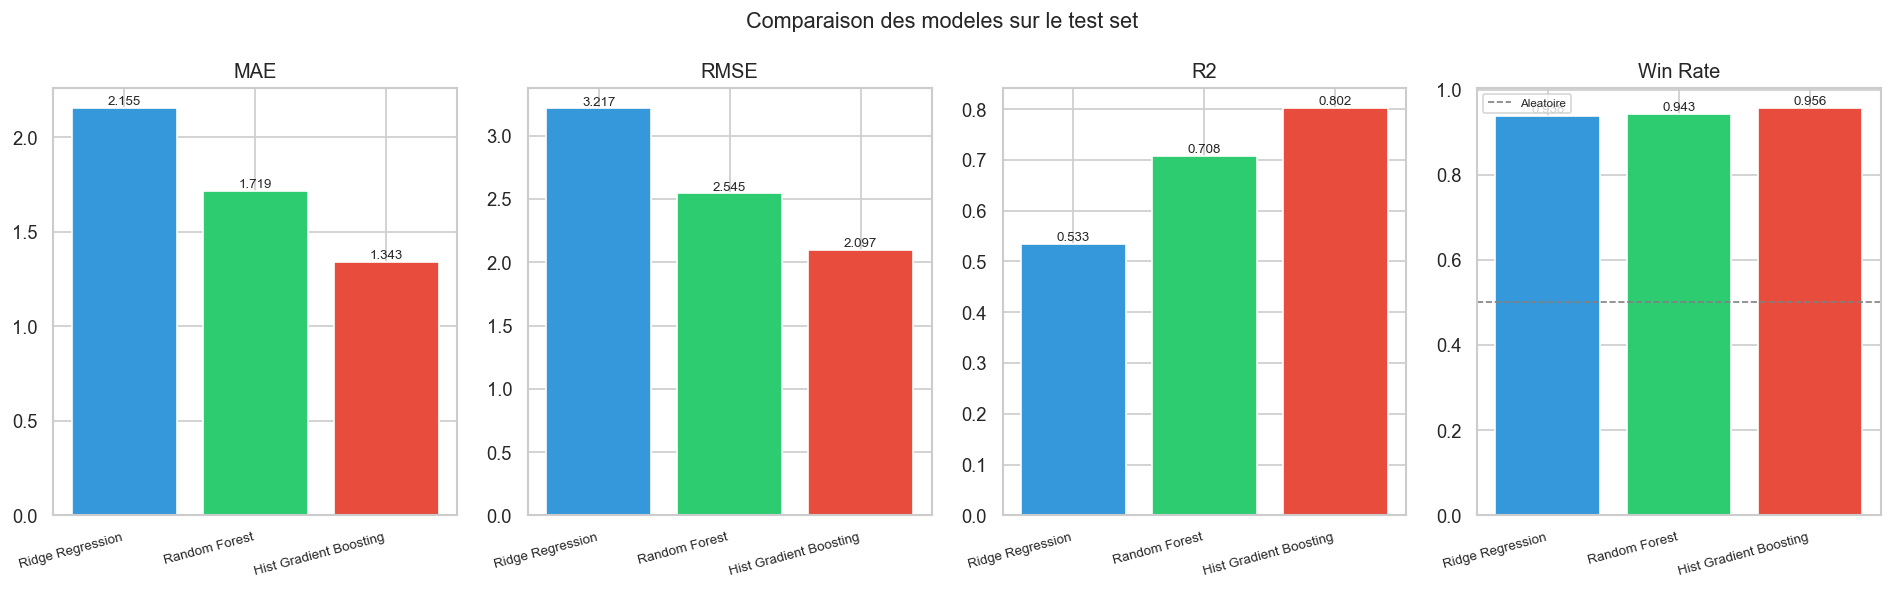

In [6]:
metrics_to_plot = ['MAE', 'RMSE', 'R2', 'Win Rate']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric]
    bars = axes[i].bar(range(len(vals)), vals, color=colors)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=15, ha='right', fontsize=8)
    axes[i].set_title(metric, fontsize=12)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if metric == 'Win Rate':
        axes[i].axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Aleatoire')
        axes[i].legend(fontsize=7)

plt.suptitle('Comparaison des modeles sur le test set', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/07_comparaison_metriques.png', bbox_inches='tight')
plt.show()

## 6. Predicted vs Actual — les 3 modèles

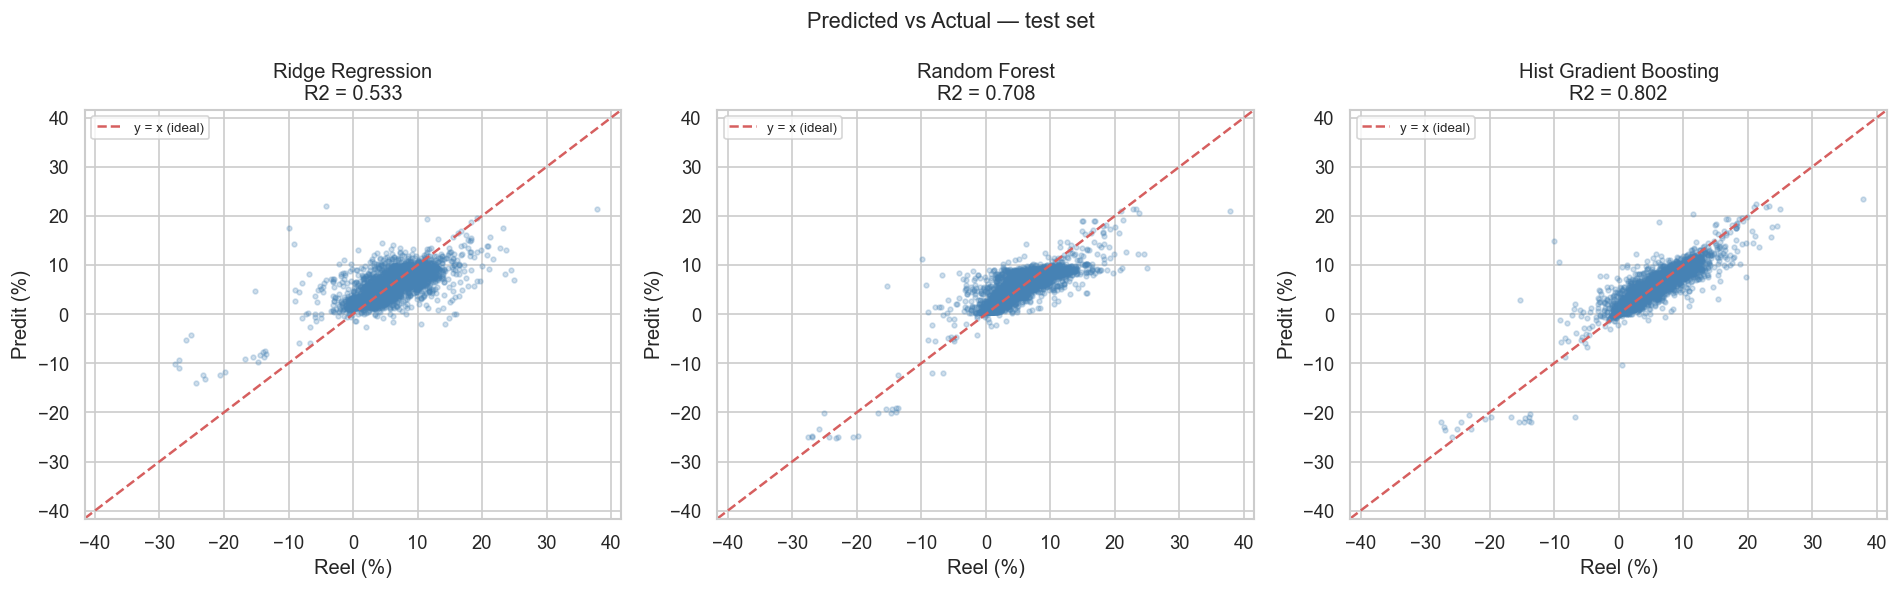

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lim = max(abs(y_test.min()), abs(y_test.max())) * 1.1

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.25, s=8, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='y = x (ideal)')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('Reel (%)')
    ax.set_ylabel('Predit (%)')
    r2 = results_df.loc[name, 'R2']
    ax.set_title(f'{name}\nR2 = {r2:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — test set', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/08_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## 7. Importance des variables — Random Forest

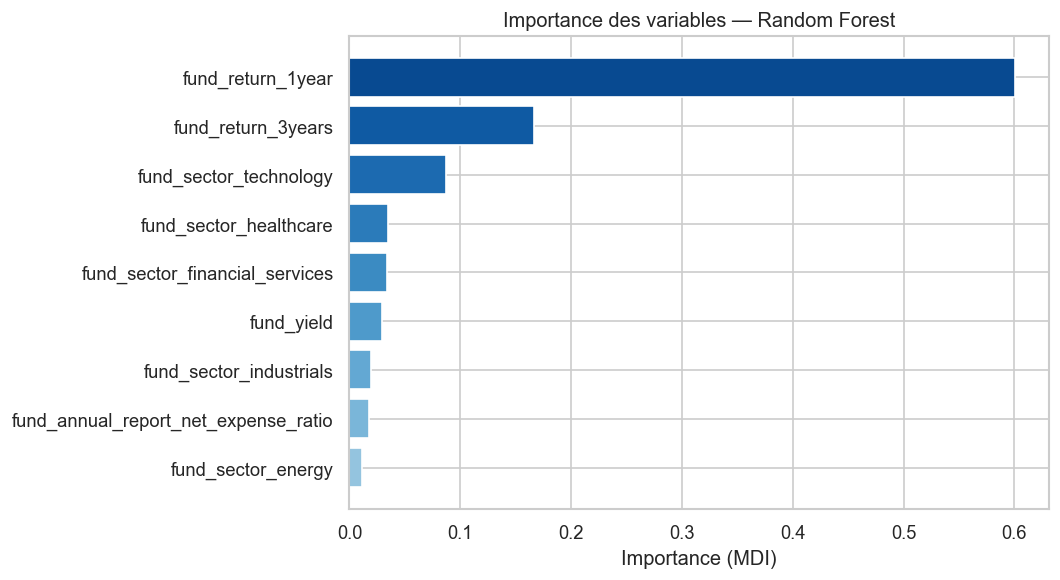

                             feature  importance
                   fund_return_1year    0.600942
                  fund_return_3years    0.166182
              fund_sector_technology    0.087127
              fund_sector_healthcare    0.034513
      fund_sector_financial_services    0.034302
                          fund_yield    0.028968
             fund_sector_industrials    0.019254
fund_annual_report_net_expense_ratio    0.017443
                  fund_sector_energy    0.011270


In [8]:
rf_pipeline = trained['Random Forest']
importances = rf_pipeline.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})\
           .sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_df)))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors_imp)
ax.set_xlabel('Importance (MDI)')
ax.set_title('Importance des variables — Random Forest')
plt.tight_layout()
plt.savefig('../plots/09_feature_importance.png', bbox_inches='tight')
plt.show()

print(imp_df.sort_values('importance', ascending=False).to_string(index=False))

## 8. Analyse des résidus — meilleur modèle (HGB)

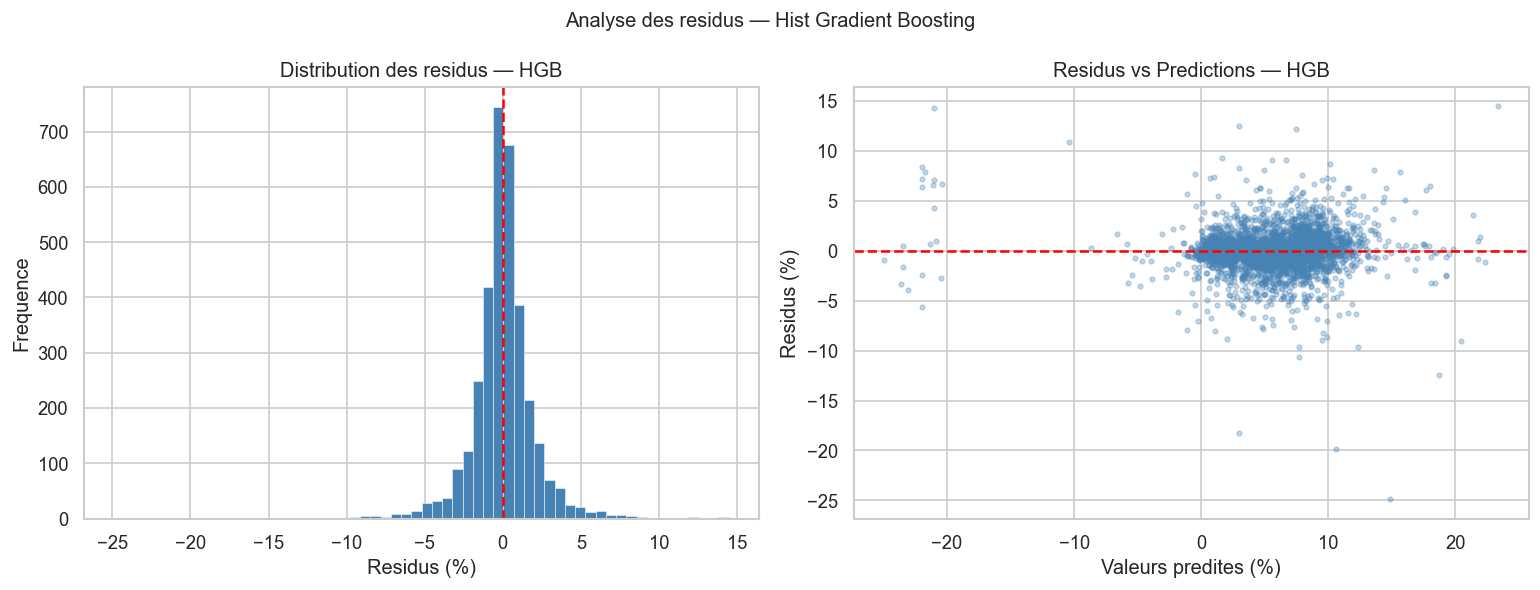

Residus — mean: 0.0004  std: 2.0973


In [9]:
y_pred_hgb = predictions['Hist Gradient Boosting']
residuals = y_test.values - y_pred_hgb

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution des résidus
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residus (%)')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution des residus — HGB')

# Résidus vs valeurs predites
axes[1].scatter(y_pred_hgb, residuals, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Valeurs predites (%)')
axes[1].set_ylabel('Residus (%)')
axes[1].set_title('Residus vs Predictions — HGB')

plt.suptitle('Analyse des residus — Hist Gradient Boosting', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/10_analyse_residus.png', bbox_inches='tight')
plt.show()

print(f'Residus — mean: {residuals.mean():.4f}  std: {residuals.std():.4f}')

## 9. Sauvegarde des modèles

In [10]:
key_map = {
    'Ridge Regression':       'ridge',
    'Random Forest':          'random_forest',
    'Hist Gradient Boosting': 'gradient_boosting',
}

for name, pipeline in trained.items():
    path = MODELS_DIR / f'{key_map[name]}.joblib'
    joblib.dump(pipeline, path)
    print(f'Sauvegarde : {path.name}')

print('\nModeles prets pour scripts/main.py')

Sauvegarde : ridge.joblib
Sauvegarde : random_forest.joblib
Sauvegarde : gradient_boosting.joblib

Modeles prets pour scripts/main.py


## 10. Synthèse

| Modèle | MAE (%) | R² | Win Rate | Commentaire |
|--------|---------|-----|----------|-------------|
| Ridge  | ~2.15   | 0.53 | 93.8%   | Baseline solide, linéaire |
| Random Forest | ~1.72 | 0.71 | 94.3% | Capture les non-linéarités |
| **HGB** | **~1.34** | **0.80** | **95.6%** | **Meilleur modèle** |

**Conclusion** : Le Hist Gradient Boosting explique **80% de la variance** du rendement futur avec une erreur moyenne de **1.34 point de pourcentage**. 

La variable `fund_return_3years` est de loin la plus prédictive, ce qui est cohérent avec la persistence des performances en finance.